##  Imports and Configuration

In [ ]:
import os
import time
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = ''          
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'        

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

import absl.logging                              # ← add this
absl.logging.set_verbosity(absl.logging.ERROR)   # ← add this

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
pd.set_option('display.max_columns', 40)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

##  Data Loading and Initial Exploration

In [2]:
df = pd.read_csv('price_data.csv', parse_dates=['date'])
df = df.set_index('date').asfreq('MS')
prices = df['avg_monthly_price']

summary = pd.DataFrame({
    'Value': [
        df.shape,
        f'{df.index.min():%b %Y} -> {df.index.max():%b %Y}',
        int(df.isna().sum().sum()),
        f'₹{prices.min():,.0f} - ₹{prices.max():,.0f}',
        f'₹{prices.mean():,.2f}',
        f'₹{prices.std():,.2f}',
        f'{prices.skew():.4f}',
        f'{prices.kurtosis():.4f}',
    ]
}, index=['Shape', 'Date range', 'Missing values', 'Price range', 'Mean', 'Std dev', 'Skewness', 'Kurtosis'])
summary

,Value
Shape,"(249, 1)"
Date range,Jan 2005 -> Sep 2025
Missing values,0
Price range,"₹3,500 - ₹16,163"
Mean,"₹7,918.89"
Std dev,"₹2,804.99"
Skewness,0.9877
Kurtosis,0.7418


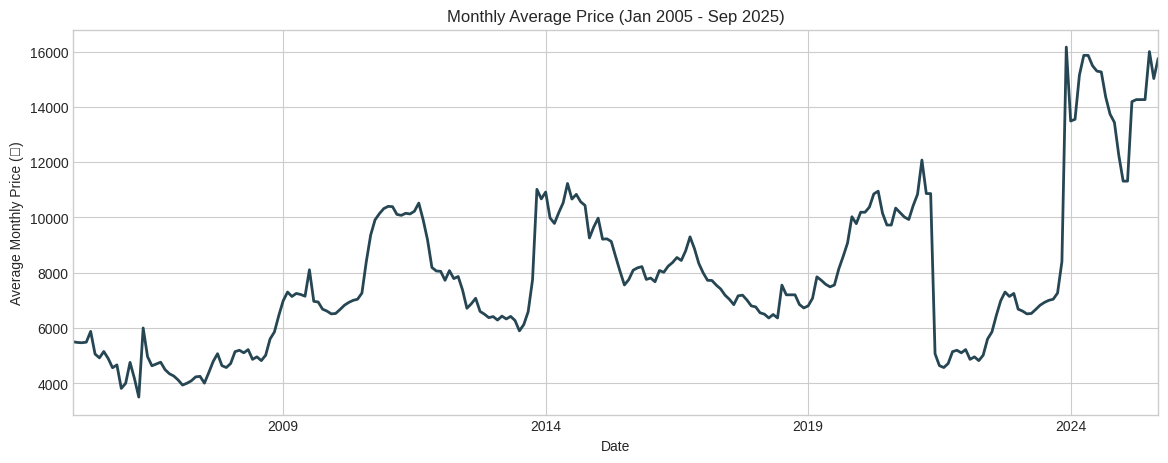

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
prices.plot(ax=ax, color='#264653', linewidth=2)
ax.set_title('Monthly Average Price (Jan 2005 - Sep 2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Monthly Price (₹)')
plt.show()

##  Data Cleaning



In [4]:
expected = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
missing = expected.difference(df.index)

cleaning_checks = pd.DataFrame({
    'Result': [
        int(df.isnull().sum().sum()),
        len(expected),
        len(missing),
        int(df.index.duplicated().sum()),
        int(df.duplicated().sum()),
    ]
}, index=['Null values', 'Expected months', 'Missing months', 'Duplicate dates', 'Duplicate price rows'])
cleaning_checks

,Result
Null values,0
Expected months,249
Missing months,0
Duplicate dates,0
Duplicate price rows,52


In [5]:
Q1, Q3 = prices.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
iqr_outliers = prices[(prices < lower) | (prices > upper)]
z_scores = pd.Series(np.abs(stats.zscore(prices)), index=prices.index)
z_outliers = prices[z_scores > 3]

outlier_summary = pd.DataFrame({
    'Value': [Q1, Q3, IQR, lower, upper, len(iqr_outliers), len(z_outliers)]
}, index=['Q1', 'Q3', 'IQR', 'Lower bound', 'Upper bound', 'IQR outliers found', 'Z-score outliers found'])
outlier_summary.round(2)

,Value
Q1,6123.0
Q3,9783.0
IQR,3660.0
Lower bound,633.0
Upper bound,15273.0
IQR outliers found,7.0
Z-score outliers found,0.0


In [6]:
iqr_outliers.rename('price').to_frame()

,price
date,
2023-12-01,16163
2024-04-01,15863
2024-05-01,15863
2024-06-01,15488
2024-07-01,15294
2025-07-01,16000
2025-09-01,15750


In [7]:
rolling_mean = prices.rolling(12).mean()
residuals = (prices - rolling_mean).dropna()
anomalies = residuals[np.abs(residuals - residuals.mean()) > 2.5 * residuals.std()]

anomaly_df = pd.DataFrame({
    'actual_price': prices.loc[anomalies.index],
    'rolling_residual': anomalies.round(2),
})
anomaly_df

,actual_price,rolling_residual
date,,
2013-11-01,11016,4192.00
2021-06-01,5070,-4932.92
2021-07-01,4638,-4941.00
2021-08-01,4569,-4580.33
2021-09-01,4715,-3965.75
2023-12-01,16163,8445.50
2024-01-01,13488,5203.25
2024-02-01,13550,4687.08
2024-03-01,15150,5567.08


##  EDA

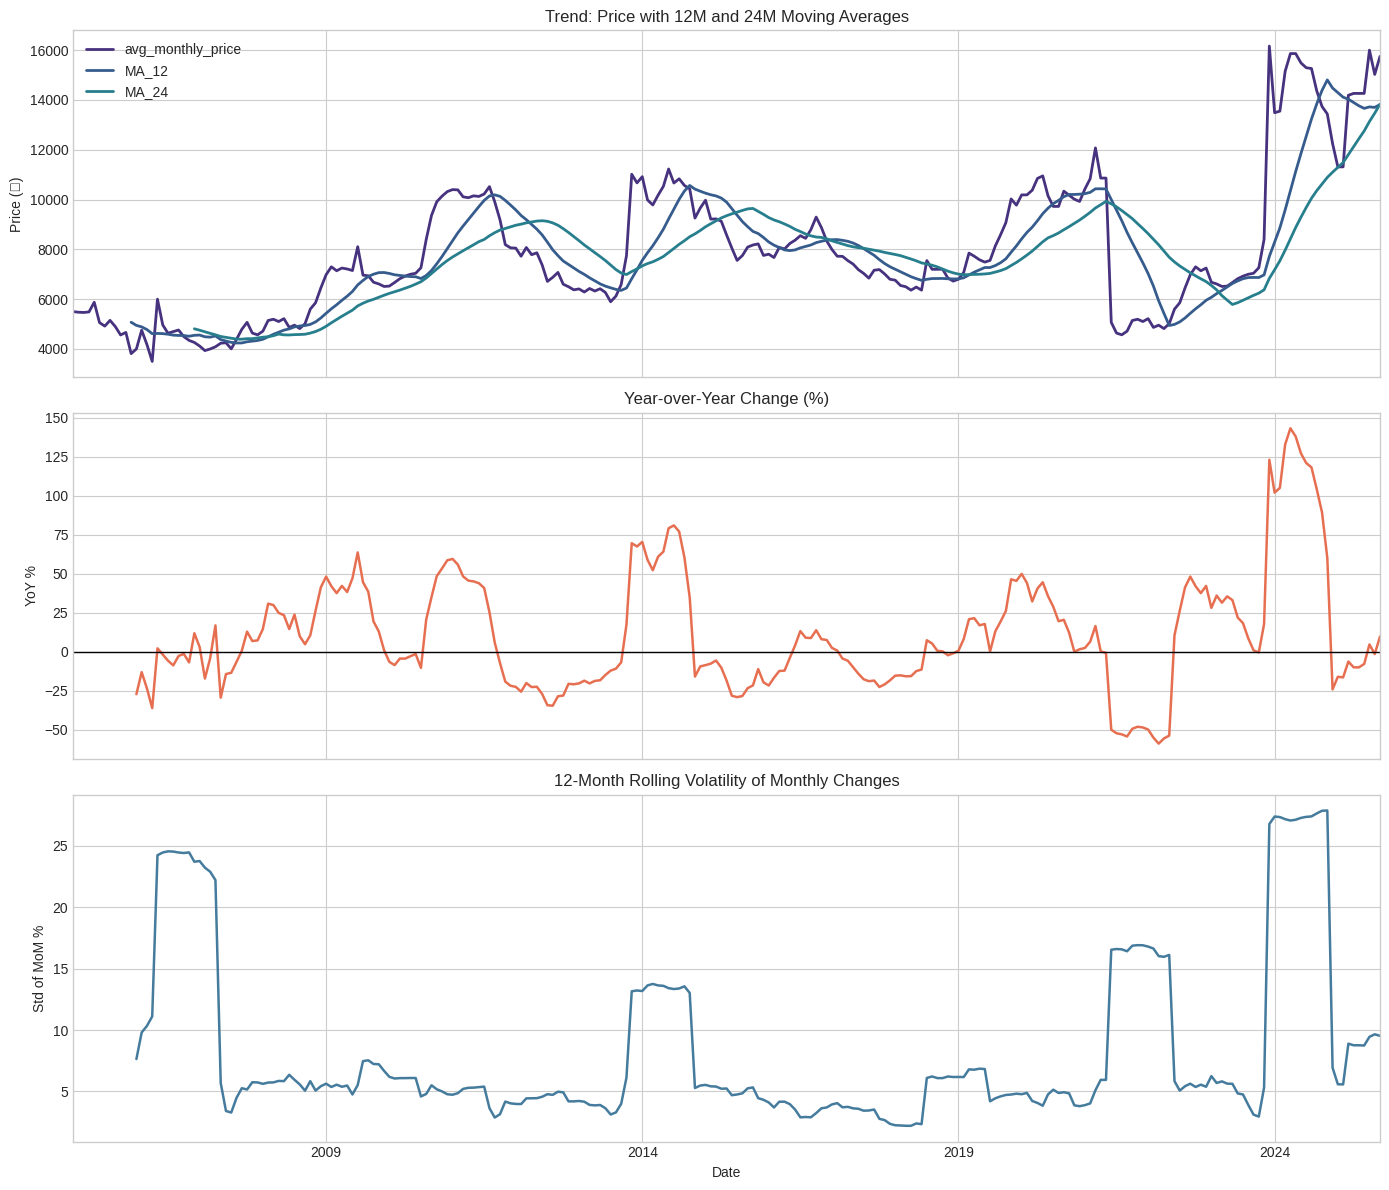

In [8]:
eda = df.copy()
eda['MA_3'] = prices.rolling(3).mean()
eda['MA_12'] = prices.rolling(12).mean()
eda['MA_24'] = prices.rolling(24).mean()
eda['MoM_%'] = prices.pct_change() * 100
eda['YoY_%'] = prices.pct_change(12) * 100
eda['rolling_vol_12'] = eda['MoM_%'].rolling(12).std()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
eda[['avg_monthly_price', 'MA_12', 'MA_24']].plot(ax=axes[0], linewidth=2)
axes[0].set_title('Trend: Price with 12M and 24M Moving Averages')
axes[0].set_ylabel('Price (₹)')
eda['YoY_%'].plot(ax=axes[1], color='#e76f51', linewidth=1.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Year-over-Year Change (%)')
axes[1].set_ylabel('YoY %')
eda['rolling_vol_12'].plot(ax=axes[2], color='#457b9d', linewidth=1.8)
axes[2].set_title('12-Month Rolling Volatility of Monthly Changes')
axes[2].set_ylabel('Std of MoM %')
axes[2].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [9]:
yearly_stats = prices.groupby(prices.index.year).agg(['mean', 'std', 'min', 'max']).round(2)
yearly_stats['YoY mean %'] = yearly_stats['mean'].pct_change().mul(100).round(2)
yearly_stats.tail(12)

,mean,std,min,max,YoY mean %
date,,,,,
2014,10335.92,577.81,9257,11228,43.92
2015,8477.00,748.27,7556,9974,-17.99
2016,8372.83,463.46,7673,9297,-1.23
2017,7302.67,377.35,6800,7994,-12.78
2018,6812.42,391.30,6362,7550,-6.71
2019,8139.67,1025.41,6800,10025,19.48
2020,10216.83,380.97,9725,10950,25.52
2021,7458.00,3166.42,4569,12075,-27.00
2022,5954.33,1010.47,4819,7300,-20.16


In [10]:
regime_bins = [pd.Timestamp('2005-01-01'), pd.Timestamp('2009-01-01'), pd.Timestamp('2014-01-01'),
               pd.Timestamp('2019-01-01'), pd.Timestamp('2022-01-01'), pd.Timestamp('2025-10-01')]
regime_labels = ['2005-2008 stable base', '2009-2013 boom/decline', '2014-2018 softening',
                 '2019-2021 recovery/crash', '2022-2025 surge']
regime = pd.cut(prices.index, bins=regime_bins, labels=regime_labels, right=False)
regime_stats = prices.groupby(regime, observed=True).agg(['count', 'mean', 'std', 'min', 'max']).round(2)
regime_stats['range'] = regime_stats['max'] - regime_stats['min']
regime_stats

,count,mean,std,min,max,range
2005-2008 stable base,48,4801.42,621.30,3500,6450,2950
2009-2013 boom/decline,60,7862.73,1513.18,5896,11016,5120
2014-2018 softening,60,8260.17,1327.80,6362,11228,4866
2019-2021 recovery/crash,36,8604.83,2223.34,4569,12075,7506
2022-2025 surge,45,10315.29,4188.61,4819,16163,11344


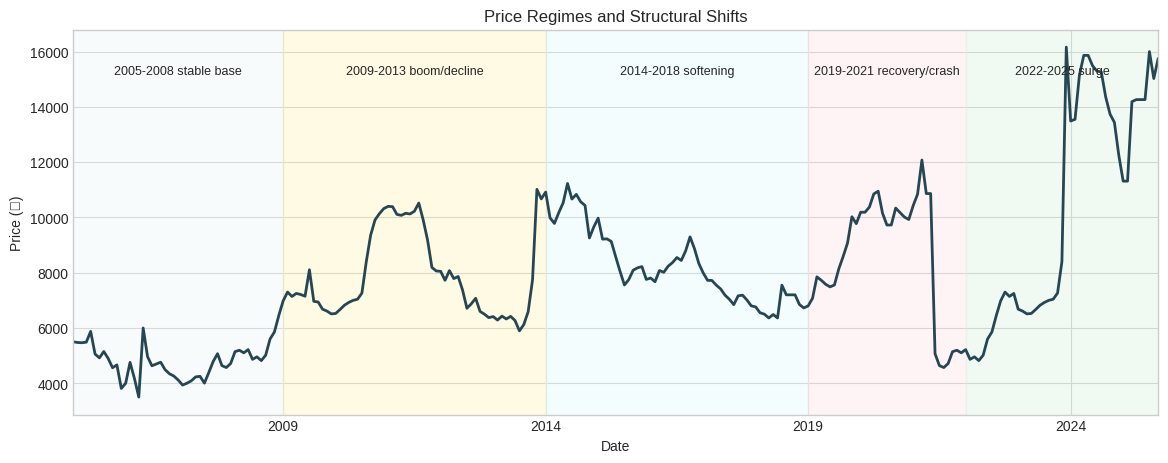

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
prices.plot(ax=ax, color='#264653', linewidth=2)
colors = ['#edf6f9', '#fff3b0', '#e0fbfc', '#fde2e4', '#d8f3dc']
for start, end, label, color in zip(regime_bins[:-1], regime_bins[1:], regime_labels, colors):
    ax.axvspan(start, end, color=color, alpha=0.35)
    mid = start + (end - start) / 2
    ax.text(mid, prices.max() * 0.96, label, ha='center', va='top', fontsize=9)
ax.set_title('Price Regimes and Structural Shifts')
ax.set_xlabel('Date')
ax.set_ylabel('Price (₹)')
plt.show()

In [12]:
monthly_stats = prices.groupby(prices.index.month).agg(['mean', 'std']).round(2)
monthly_stats.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_stats['seasonal_index_vs_avg_%'] = ((monthly_stats['mean'] / prices.mean() - 1) * 100).round(2)
monthly_stats

,mean,std,seasonal_index_vs_avg_%
Jan,7822.48,2603.95,-1.22
Feb,7774.67,2514.20,-1.82
Mar,8086.86,3033.08,2.12
Apr,8032.43,3144.40,1.43
May,8210.24,2970.86,3.68
Jun,7770.19,3000.08,-1.88
Jul,7812.67,3186.51,-1.34
Aug,7865.52,3039.29,-0.67
Sep,8044.38,2970.17,1.58
Oct,7741.95,2327.12,-2.23


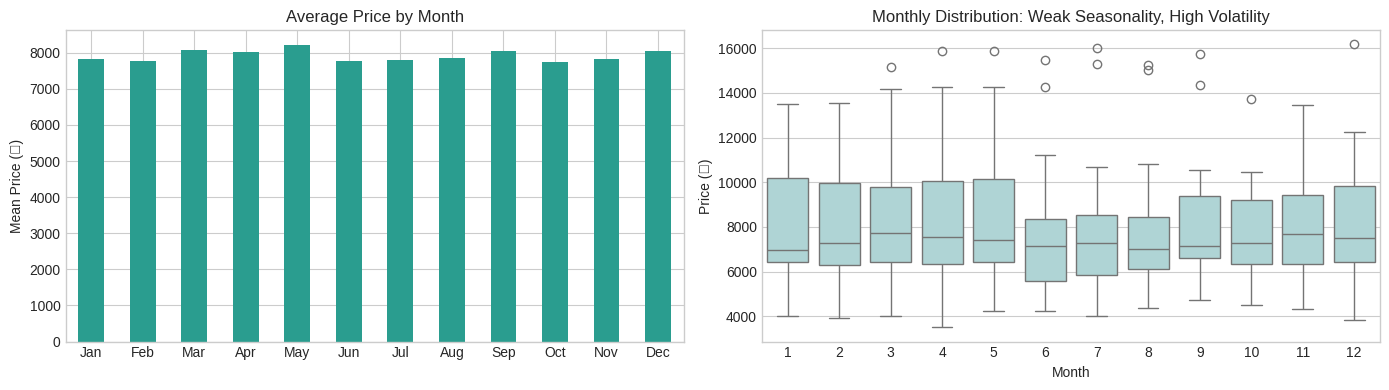

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
monthly_stats['mean'].plot(kind='bar', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Average Price by Month')
axes[0].set_ylabel('Mean Price (₹)')
axes[0].tick_params(axis='x', rotation=0)
sns.boxplot(x=prices.index.month, y=prices.values, ax=axes[1], color='#a8dadc')
axes[1].set_title('Monthly Distribution: Weak Seasonality, High Volatility')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Price (₹)')
plt.tight_layout()
plt.show()

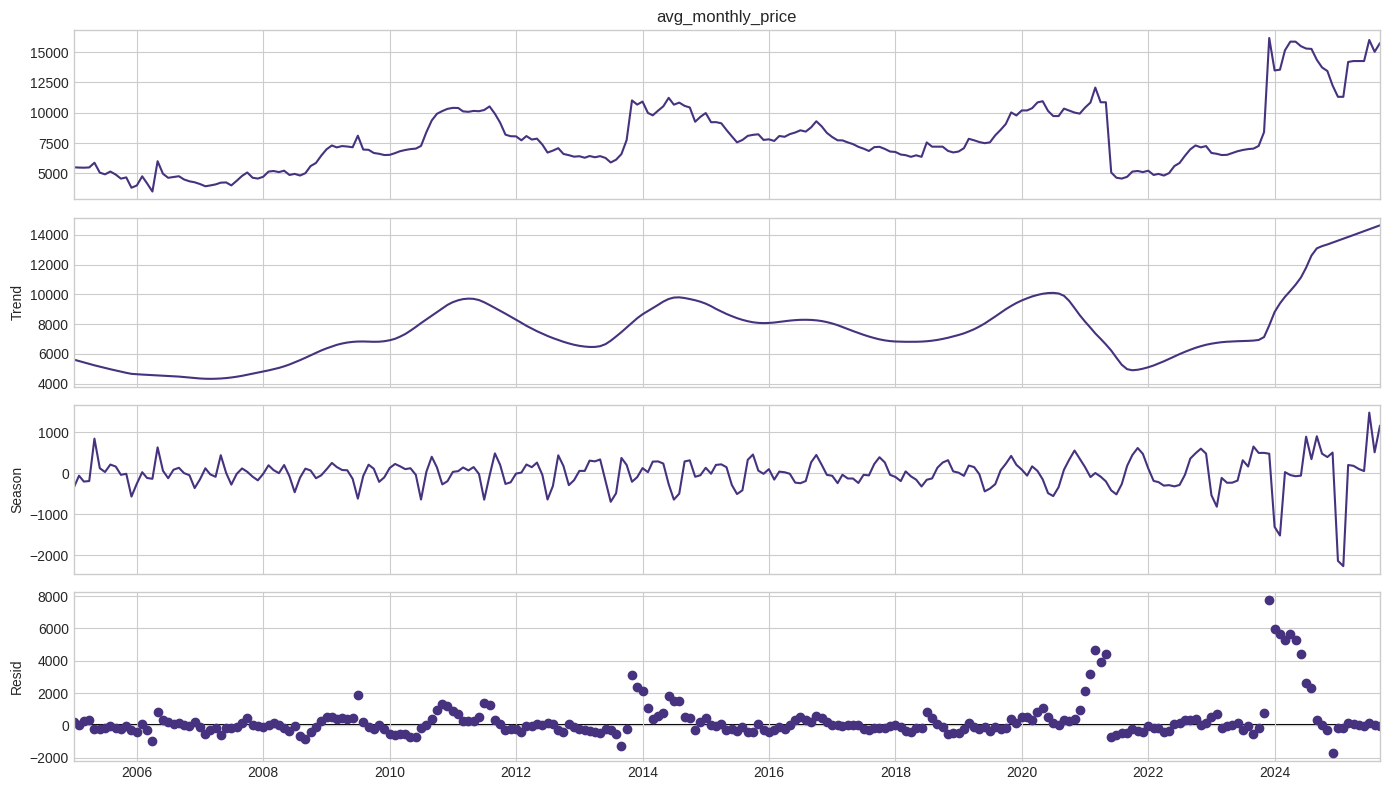

,strength
trend_strength,0.810
seasonal_strength,0.016


In [14]:
stl = STL(prices, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

stl_strength = {
    'trend_strength': max(0, 1 - np.var(stl.resid.dropna()) / np.var((stl.trend + stl.resid).dropna())),
    'seasonal_strength': max(0, 1 - np.var(stl.resid.dropna()) / np.var((stl.seasonal + stl.resid).dropna())),
}
pd.Series(stl_strength).round(3).to_frame('strength')

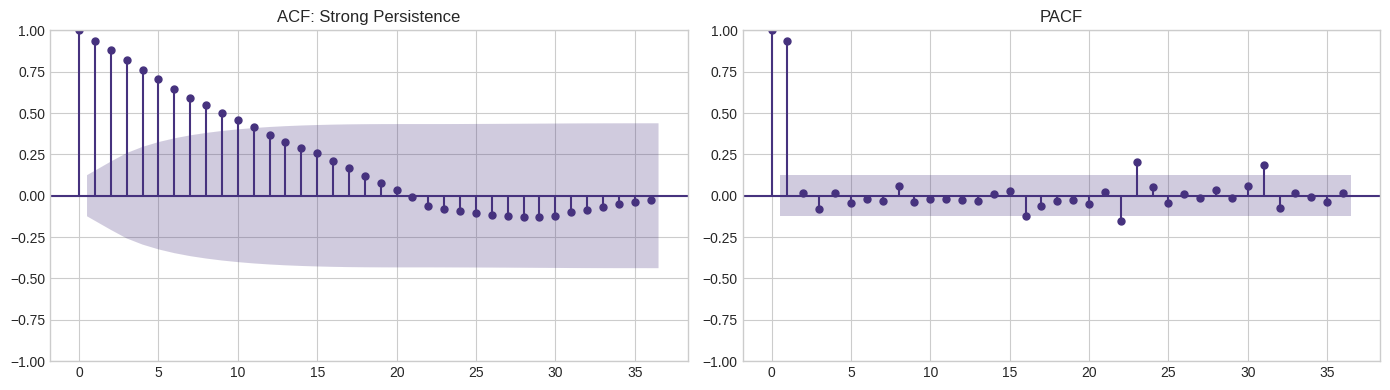

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(prices, lags=36, ax=axes[0])
plot_pacf(prices, lags=36, ax=axes[1], method='ywm')
axes[0].set_title('ACF: Strong Persistence')
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

Price distribution percentiles


,avg_monthly_price
count,249.00
mean,7918.89
std,2804.99
min,3500.00
1%,3966.20
5%,4361.20
25%,6123.00
50%,7250.00
75%,9783.00
95%,14263.00


Recent windows compared with full history


,All data,Last 24 months,Last 12 months
mean,7918.89,13831.29,13817.00
median,7250.00,14263.00,14225.50
std,2804.99,2296.91,1532.71
min,3500.00,7262.00,11313.00
max,16163.00,16163.00,16000.00


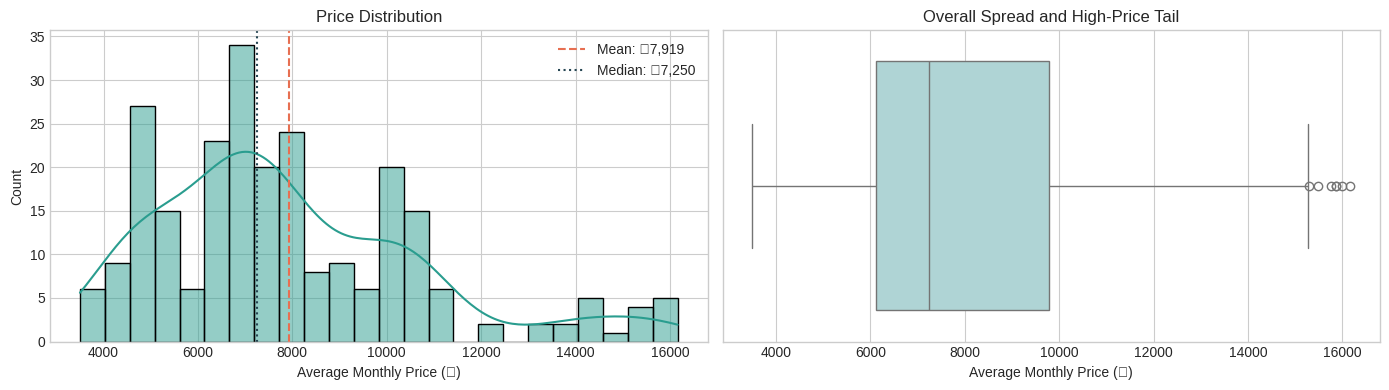

In [16]:
price_distribution = prices.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2)
window_summary = pd.DataFrame({
    'All data': prices.agg(['mean', 'median', 'std', 'min', 'max']),
    'Last 24 months': prices.tail(24).agg(['mean', 'median', 'std', 'min', 'max']),
    'Last 12 months': prices.tail(12).agg(['mean', 'median', 'std', 'min', 'max']),
}).round(2)

print('Price distribution percentiles')
display(price_distribution.to_frame('avg_monthly_price'))
print('Recent windows compared with full history')
display(window_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(prices, kde=True, bins=24, ax=axes[0], color='#2a9d8f')
axes[0].axvline(prices.mean(), color='#e76f51', linestyle='--', label=f'Mean: ₹{prices.mean():,.0f}')
axes[0].axvline(prices.median(), color='#264653', linestyle=':', label=f'Median: ₹{prices.median():,.0f}')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Average Monthly Price (₹)')
axes[0].legend()

sns.boxplot(x=prices, ax=axes[1], color='#a8dadc')
axes[1].set_title('Overall Spread and High-Price Tail')
axes[1].set_xlabel('Average Monthly Price (₹)')
plt.tight_layout()
plt.show()

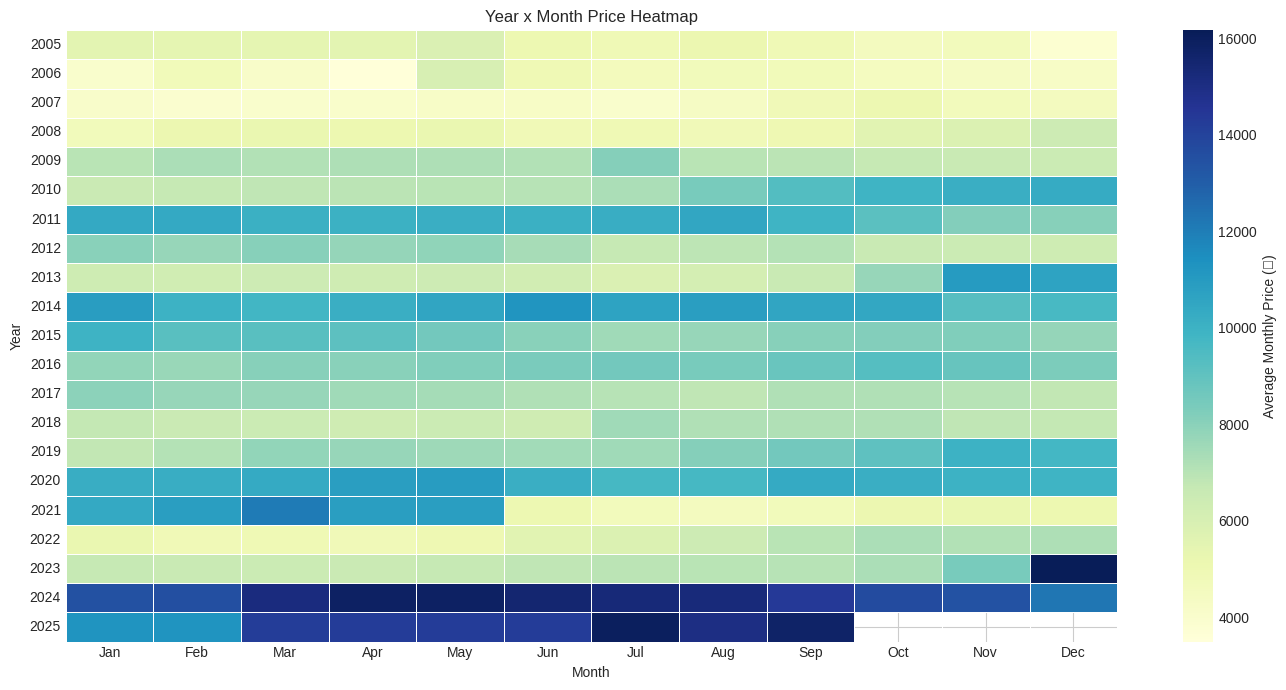

In [17]:
heatmap_df = df.copy()
heatmap_df['year'] = heatmap_df.index.year
heatmap_df['month'] = heatmap_df.index.month
month_year_matrix = heatmap_df.pivot_table(values='avg_monthly_price', index='year', columns='month')
month_year_matrix.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(month_year_matrix, cmap='YlGnBu', linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': 'Average Monthly Price (₹)'})
ax.set_title('Year x Month Price Heatmap')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

In [18]:
change_df = pd.DataFrame({
    'price': prices,
    'mom_change': prices.diff(),
    'mom_change_%': prices.pct_change().mul(100),
    'yoy_change': prices.diff(12),
    'yoy_change_%': prices.pct_change(12).mul(100),
})

largest_mom_up = change_df.nlargest(8, 'mom_change')[['price', 'mom_change', 'mom_change_%']].round(2)
largest_mom_down = change_df.nsmallest(8, 'mom_change')[['price', 'mom_change', 'mom_change_%']].round(2)
largest_yoy_up = change_df.nlargest(8, 'yoy_change')[['price', 'yoy_change', 'yoy_change_%']].round(2)
largest_yoy_down = change_df.nsmallest(8, 'yoy_change')[['price', 'yoy_change', 'yoy_change_%']].round(2)

print('Largest month-over-month increases')
display(largest_mom_up)
print('Largest month-over-month drops')
display(largest_mom_down)
print('Largest year-over-year increases')
display(largest_yoy_up)
print('Largest year-over-year drops')
display(largest_yoy_down)

Largest month-over-month increases


,price,mom_change,mom_change_%
date,,,
2023-12-01,16163,7763.0,92.42
2013-11-01,11016,3272.0,42.25
2025-03-01,14188,2875.0,25.41
2006-05-01,6000,2500.0,71.43
2025-07-01,16000,1737.0,12.18
2024-03-01,15150,1600.0,11.81
2021-03-01,12075,1237.0,11.41
2018-07-01,7550,1188.0,18.67


Largest month-over-month drops


,price,mom_change,mom_change_%
date,,,
2021-06-01,5070,-5793.0,-53.33
2024-01-01,13488,-2675.0,-16.55
2021-04-01,10863,-1212.0,-10.04
2024-12-01,12250,-1188.0,-8.84
2014-11-01,9257,-1177.0,-11.28
2009-08-01,6964,-1142.0,-14.09
2006-06-01,4964,-1036.0,-17.27
2011-11-01,8190,-997.0,-10.85


Largest year-over-year increases


,price,yoy_change,yoy_change_%
date,,,
2024-04-01,15863,9338.0,143.11
2024-05-01,15863,9194.0,137.86
2023-12-01,16163,8913.0,122.94
2024-06-01,15488,8665.0,127.00
2024-03-01,15150,8640.0,132.72
2024-07-01,15294,8369.0,120.85
2024-08-01,15263,8263.0,118.04
2024-09-01,14363,7323.0,104.02


Largest year-over-year drops


,price,yoy_change,yoy_change_%
date,,,
2022-03-01,4956,-7119.0,-58.96
2022-04-01,4819,-6044.0,-55.64
2022-02-01,4865,-5973.0,-55.11
2022-05-01,5015,-5848.0,-53.83
2021-09-01,4715,-5623.0,-54.39
2022-01-01,5218,-5207.0,-49.95
2021-08-01,4569,-5156.0,-53.02
2021-07-01,4638,-5087.0,-52.31


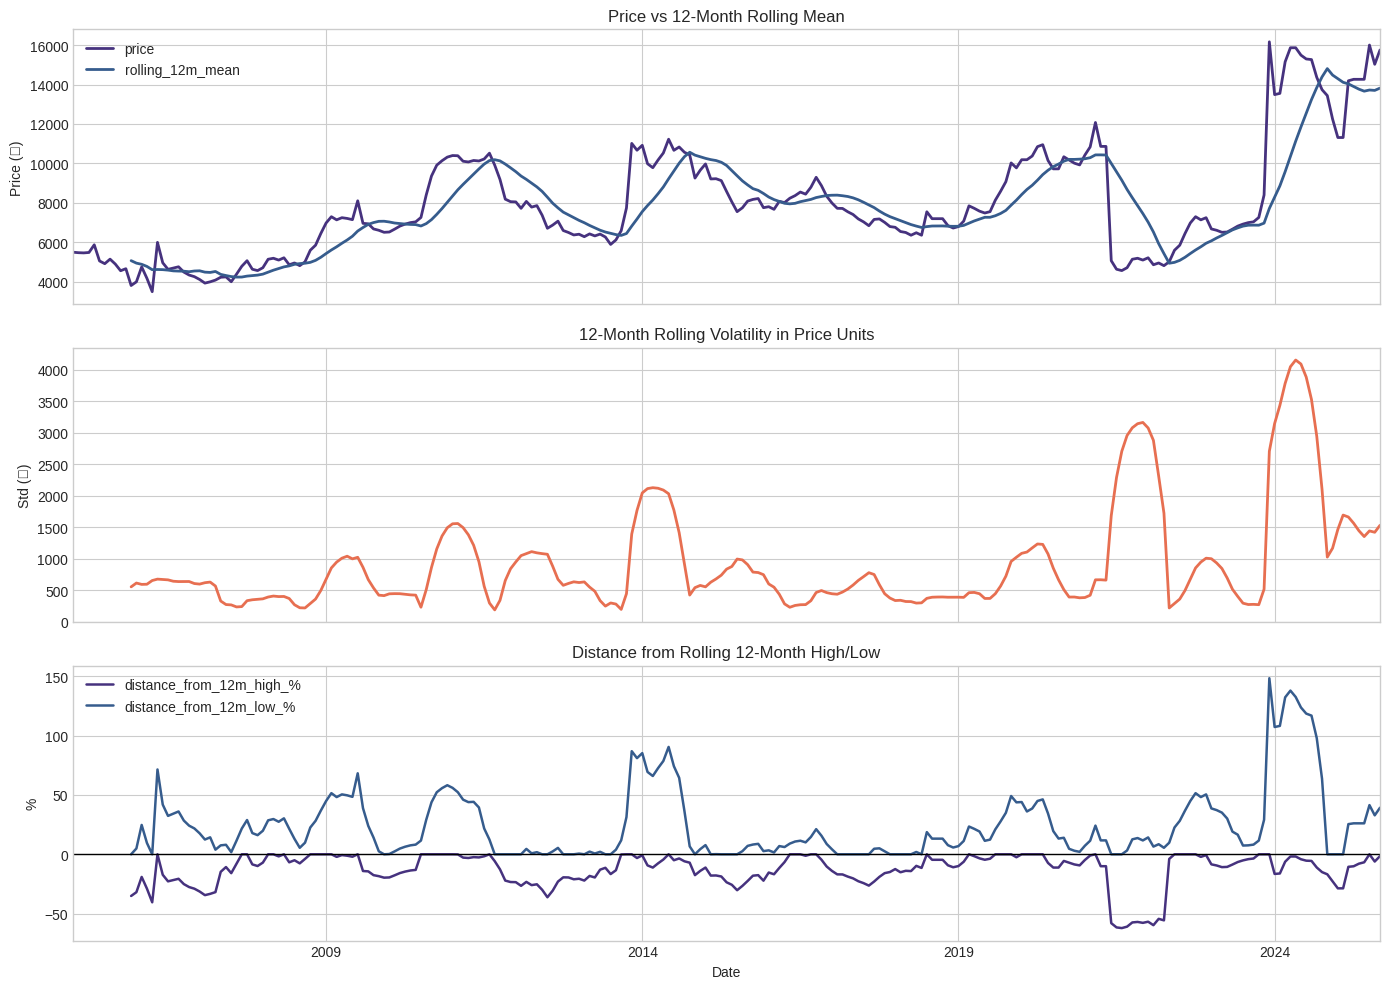

,price,rolling_12m_mean,rolling_12m_std,rolling_12m_min,rolling_12m_max,distance_from_12m_high_%,distance_from_12m_low_%
date,,,,,,,
2024-10-01,13738,14385.25,2103.47,8400.0,16163.0,-15.00,63.55
2024-11-01,13438,14805.08,1028.21,13438.0,16163.0,-16.86,0.00
2024-12-01,12250,14479.00,1169.22,12250.0,15863.0,-22.78,0.00
2025-01-01,11313,14297.75,1467.38,11313.0,15863.0,-28.68,0.00
2025-02-01,11313,14111.33,1695.39,11313.0,15863.0,-28.68,0.00
2025-03-01,14188,14031.17,1664.27,11313.0,15863.0,-10.56,25.41
2025-04-01,14263,13897.83,1565.32,11313.0,15863.0,-10.09,26.08
2025-05-01,14263,13764.50,1446.33,11313.0,15488.0,-7.91,26.08
2025-06-01,14263,13662.42,1353.90,11313.0,15294.0,-6.74,26.08


In [19]:
rolling_risk = pd.DataFrame(index=prices.index)
rolling_risk['price'] = prices
rolling_risk['rolling_12m_mean'] = prices.rolling(12).mean()
rolling_risk['rolling_12m_std'] = prices.rolling(12).std()
rolling_risk['rolling_12m_min'] = prices.rolling(12).min()
rolling_risk['rolling_12m_max'] = prices.rolling(12).max()
rolling_risk['distance_from_12m_high_%'] = ((prices / rolling_risk['rolling_12m_max']) - 1).mul(100)
rolling_risk['distance_from_12m_low_%'] = ((prices / rolling_risk['rolling_12m_min']) - 1).mul(100)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
rolling_risk[['price', 'rolling_12m_mean']].plot(ax=axes[0], linewidth=2)
axes[0].set_title('Price vs 12-Month Rolling Mean')
axes[0].set_ylabel('Price (₹)')

rolling_risk['rolling_12m_std'].plot(ax=axes[1], color='#e76f51', linewidth=2)
axes[1].set_title('12-Month Rolling Volatility in Price Units')
axes[1].set_ylabel('Std (₹)')

rolling_risk[['distance_from_12m_high_%', 'distance_from_12m_low_%']].plot(ax=axes[2], linewidth=1.8)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Distance from Rolling 12-Month High/Low')
axes[2].set_ylabel('%')
axes[2].set_xlabel('Date')
plt.tight_layout()
plt.show()

rolling_risk.tail(12).round(2)

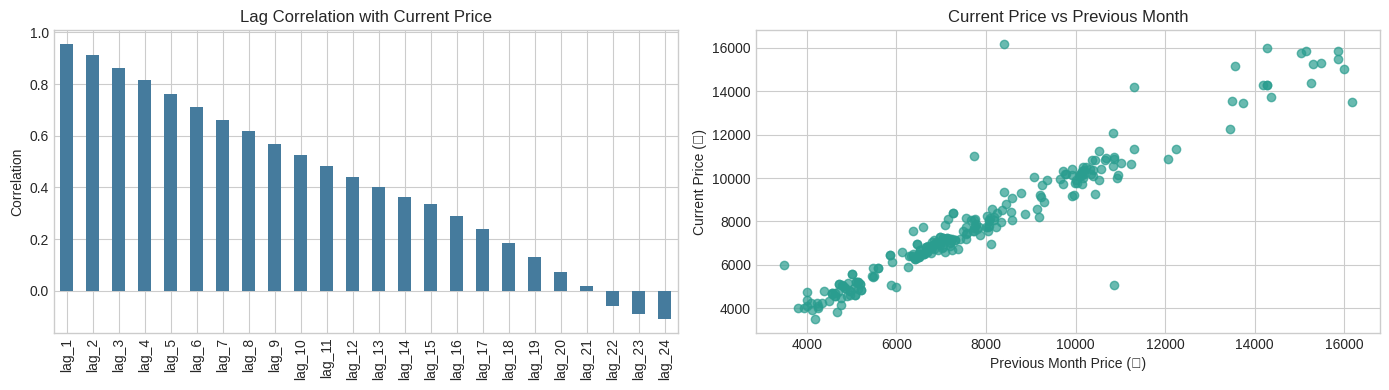

,correlation,abs_correlation
lag_1,0.955,0.955
lag_2,0.911,0.911
lag_3,0.863,0.863
lag_4,0.815,0.815
lag_5,0.763,0.763
lag_6,0.713,0.713
lag_7,0.662,0.662
lag_8,0.617,0.617
lag_9,0.569,0.569
lag_10,0.525,0.525


In [20]:
lag_corr = pd.DataFrame({
    f'lag_{lag}': prices.shift(lag).corr(prices)
    for lag in range(1, 25)
}, index=['correlation']).T
lag_corr['abs_correlation'] = lag_corr['correlation'].abs()
lag_corr = lag_corr.sort_values('abs_correlation', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lag_corr.sort_index(key=lambda idx: idx.str.extract(r'(\d+)')[0].astype(int))['correlation'].plot(kind='bar', ax=axes[0], color='#457b9d')
axes[0].set_title('Lag Correlation with Current Price')
axes[0].set_ylabel('Correlation')
axes[0].tick_params(axis='x', rotation=90)

axes[1].scatter(prices.shift(1), prices, alpha=0.7, color='#2a9d8f')
axes[1].set_title('Current Price vs Previous Month')
axes[1].set_xlabel('Previous Month Price (₹)')
axes[1].set_ylabel('Current Price (₹)')
plt.tight_layout()
plt.show()

lag_corr.head(10).round(3)

In [21]:
eda_insights = pd.Series({
    'Recent level': f"Last 12-month mean is ₹{prices.tail(12).mean():,.0f} vs full-history mean ₹{prices.mean():,.0f}",
    'Seasonality': f"Monthly seasonal spread is only {monthly_stats['seasonal_index_vs_avg_%'].max() - monthly_stats['seasonal_index_vs_avg_%'].min():.2f} percentage points around the average",
    'Persistence': f"Lag-1 correlation is {prices.shift(1).corr(prices):.3f}, confirming strong month-to-month persistence",
    'Volatility': f"Highest 12-month rolling std is ₹{rolling_risk['rolling_12m_std'].max():,.0f}",
    'Recent position': f"Sep 2025 is {rolling_risk['distance_from_12m_high_%'].iloc[-1]:.1f}% from its rolling 12-month high and {rolling_risk['distance_from_12m_low_%'].iloc[-1]:.1f}% above its rolling 12-month low",
})
eda_insights.to_frame('Insight')

,Insight
Recent level,"Last 12-month mean is ₹13,817 vs full-history ..."
Seasonality,Monthly seasonal spread is only 5.91 percentag...
Persistence,"Lag-1 correlation is 0.955, confirming strong ..."
Volatility,"Highest 12-month rolling std is ₹4,158"
Recent position,Sep 2025 is -1.6% from its rolling 12-month hi...


##  Stationarity Tests

In [22]:
def stationarity_table(series, label, kpss_regression='ct'):
    adf = adfuller(series, autolag='AIC')
    kp = kpss(series, regression=kpss_regression, nlags='auto')
    return pd.DataFrame({
        'Test statistic': [adf[0], kp[0]],
        'p-value': [adf[1], kp[1]],
        'Stationary?': ['Yes' if adf[1] < 0.05 else 'No', 'Yes' if kp[1] > 0.05 else 'No']
    }, index=[f'ADF - {label}', f'KPSS - {label}']).round(4)

pd.concat([
    stationarity_table(prices, 'Original', 'ct'),
    stationarity_table(prices.diff().dropna(), '1st Difference', 'c')
])

/tmp/ipykernel_64679/3545257737.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(series, regression=kpss_regression, nlags='auto')


,Test statistic,p-value,Stationary?
ADF - Original,-1.6311,0.4669,No
KPSS - Original,0.1287,0.0821,Yes
ADF - 1st Difference,-16.1384,0.0000,Yes
KPSS - 1st Difference,0.0859,0.1000,Yes


##  Train/Test Split

In [23]:
train = df[:'2024-09-01']
test = df['2024-10-01':'2025-09-01']
y_train = train['avg_monthly_price']
y_test = test['avg_monthly_price']

pd.DataFrame({
    'Period': [f'{train.index.min():%b %Y} -> {train.index.max():%b %Y}', f'{test.index.min():%b %Y} -> {test.index.max():%b %Y}'],
    'Months': [len(train), len(test)]
}, index=['Train', 'Test'])

,Period,Months
Train,Jan 2005 -> Sep 2024,237
Test,Oct 2024 -> Sep 2025,12


In [24]:
def evaluate(name, y_true, y_pred, category=None, training_time=None, setup='Recursive'):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    row = {
        'Model': name,
        'Category': category,
        'Setup': setup,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        'R2': r2_score(y_true, y_pred),
    }
    if training_time is not None:
        row['Training Time (s)'] = training_time
    return row

def create_features(data, lags=[1, 2, 3, 6, 12]):
    feat = pd.DataFrame(index=data.index)
    feat['price'] = data['avg_monthly_price']
    for lag in lags:
        feat[f'lag_{lag}'] = feat['price'].shift(lag)
    feat['rolling_mean_3'] = feat['price'].shift(1).rolling(3).mean()
    feat['rolling_mean_6'] = feat['price'].shift(1).rolling(6).mean()
    feat['rolling_mean_12'] = feat['price'].shift(1).rolling(12).mean()
    feat['rolling_std_6'] = feat['price'].shift(1).rolling(6).std()
    feat['rolling_std_12'] = feat['price'].shift(1).rolling(12).std()
    feat['month'] = feat.index.month
    feat['quarter'] = feat.index.quarter
    feat['year'] = feat.index.year
    feat['month_sin'] = np.sin(2 * np.pi * feat['month'] / 12)
    feat['month_cos'] = np.cos(2 * np.pi * feat['month'] / 12)
    feat['price_diff_1'] = feat['price'].shift(1).diff()
    feat['price_diff_12'] = feat['price'].shift(1) - feat['price'].shift(12)
    return feat

def recursive_predict_ml(model, history_df, forecast_dates, feature_cols, scaler=None):
    history = history_df.copy()
    preds = []
    for fdate in forecast_dates:
        history.loc[fdate, 'avg_monthly_price'] = np.nan
        row = create_features(history).loc[fdate, feature_cols].copy()
        row['month'] = fdate.month
        row['quarter'] = fdate.quarter
        row['year'] = fdate.year
        row['month_sin'] = np.sin(2 * np.pi * fdate.month / 12)
        row['month_cos'] = np.cos(2 * np.pi * fdate.month / 12)
        X_row = pd.DataFrame([row], columns=feature_cols)
        if scaler is not None:
            X_row = scaler.transform(X_row)
        pred = float(model.predict(X_row)[0])
        preds.append(pred)
        history.loc[fdate, 'avg_monthly_price'] = pred
    return pd.Series(preds, index=forecast_dates)

## Model Building and Verified Evaluation

In [25]:
results = []
predictions = pd.DataFrame(index=y_test.index)
predictions['Actual'] = y_test

In [26]:
# ARIMA model.
t0 = time.time()
arima_model = auto_arima(y_train, seasonal=False, stepwise=True, suppress_warnings=True, max_p=5, max_q=5, max_d=2)
arima_pred = pd.Series(arima_model.predict(n_periods=len(y_test)), index=y_test.index)
results.append(evaluate('ARIMA', y_test, arima_pred, 'Time Series', time.time() - t0))
predictions['ARIMA'] = arima_pred

print('ARIMA order:', arima_model.order, 'AIC:', round(arima_model.aic(), 2))

ARIMA order: (0, 1, 0) AIC: 3839.56


In [27]:
# ML models trained only on train data, then evaluated recursively.
train_features = create_features(train).dropna()
feature_cols = [c for c in train_features.columns if c != 'price']
X_train_ml = train_features[feature_cols]
y_train_ml = train_features['price']

# One-step diagnostic features from the full data, shown later only to explain the earlier optimistic result.
full_features = create_features(df).dropna()
one_step_test = full_features[(full_features.index >= test.index.min()) & (full_features.index <= test.index.max())]
X_test_one_step = one_step_test[feature_cols]
y_test_one_step = one_step_test['price']

print(f'{len(feature_cols)} engineered features')
feature_cols

17 engineered features


['lag_1',
 'lag_2',
 'lag_3',
 'lag_6',
 'lag_12',
 'rolling_mean_3',
 'rolling_mean_6',
 'rolling_mean_12',
 'rolling_std_6',
 'rolling_std_12',
 'month',
 'quarter',
 'year',
 'month_sin',
 'month_cos',
 'price_diff_1',
 'price_diff_12']

In [28]:
t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_ml, y_train_ml)
rf_pred = recursive_predict_ml(rf_model, train, y_test.index, feature_cols)
results.append(evaluate('Random Forest', y_test, rf_pred, 'ML', time.time() - t0))
predictions['Random Forest'] = rf_pred

t0 = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, random_state=SEED, objective='reg:squarederror')
xgb_model.fit(X_train_ml, y_train_ml, verbose=False)
xgb_pred = recursive_predict_ml(xgb_model, train, y_test.index, feature_cols)
results.append(evaluate('XGBoost', y_test, xgb_pred, 'ML', time.time() - t0))
predictions['XGBoost'] = xgb_pred

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

In [29]:
# LSTM: train on train only, then forecast recursively.
lookback = 12
scaler_lstm = StandardScaler().fit(train[['avg_monthly_price']].values)
train_scaled = scaler_lstm.transform(train[['avg_monthly_price']].values)

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = create_sequences(train_scaled, lookback)
X_train_lstm = X_train_lstm.reshape(-1, lookback, 1)

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1),
])
model_lstm.compile(optimizer='adam', loss='mse')

t0 = time.time()
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0,
)

lstm_history = train['avg_monthly_price'].tolist()
lstm_preds = []
for _ in range(len(test)):
    last_12 = np.array(lstm_history[-lookback:]).reshape(-1, 1)
    last_12_scaled = scaler_lstm.transform(last_12).reshape(1, lookback, 1)
    pred_scaled = model_lstm.predict(last_12_scaled, verbose=0)
    pred = float(scaler_lstm.inverse_transform(pred_scaled)[0, 0])
    lstm_preds.append(pred)
    lstm_history.append(pred)
lstm_pred = pd.Series(lstm_preds, index=y_test.index)
results.append(evaluate('LSTM', y_test, lstm_pred, 'Deep Learning', time.time() - t0))
predictions['LSTM'] = lstm_pred

print('LSTM epochs:', len(history.history['loss']))
print('LSTM parameters:', model_lstm.count_params())

LSTM epochs: 57
LSTM parameters: 29857


##  Verified Model Evaluation

In [30]:
results_df = pd.DataFrame(results).sort_values('MAPE (%)').reset_index(drop=True)
results_df.insert(0, 'Rank', results_df.index + 1)
results_df.round({'MAE': 2, 'RMSE': 2, 'MAPE (%)': 2, 'R2': 4, 'Training Time (s)': 2})

,Rank,Model,Category,Setup,MAE,RMSE,MAPE (%),R2,Training Time (s)
0,1,Random Forest,ML,Recursive,1151.05,1385.47,8.71,0.1086,0.70
1,2,ARIMA,Time Series,Recursive,1160.33,1565.74,9.12,-0.1384,0.47
2,3,XGBoost,ML,Recursive,1847.63,2086.56,12.83,-1.0218,0.69
3,4,LSTM,Deep Learning,Recursive,7705.20,8334.86,54.75,-31.2603,9.14


In [31]:
# Diagnostic: one-step-ahead ML evaluation, which uses actual earlier test values as lag inputs.
# This is useful for monitoring/nowcasting but too optimistic for a 12-month forecast made from Sep 2024.
one_step_rows = []
for name, model in [
    ('Random Forest', rf_model),
    ('XGBoost', xgb_model),
]:
    pred = model.predict(X_test_one_step)
    one_step_rows.append(evaluate(name, y_test_one_step, pred, 'ML', setup='One-step diagnostic'))

one_step_df = pd.DataFrame(one_step_rows).sort_values('MAPE (%)')
one_step_df.round({'MAE': 2, 'RMSE': 2, 'MAPE (%)': 2, 'R2': 4})

,Model,Category,Setup,MAE,RMSE,MAPE (%),R2
0,Random Forest,ML,One-step diagnostic,961.99,1166.12,7.08,0.3685
1,XGBoost,ML,One-step diagnostic,1099.10,1330.03,7.60,0.1785


**Verification finding:** one-step-ahead Random Forest and XGBoost diagnostics can look better because test-month lag features use actual earlier test prices. The recursive results table above is the fairer comparison for ARIMA, Random Forest, XGBoost, and LSTM when forecasting Oct 2024 to Sep 2025 from information available only up to Sep 2024.

In [32]:
pred_display = predictions.copy()
pred_display.index = pred_display.index.strftime('%Y-%m')
pred_display.round(0).astype(int)

,Actual,ARIMA,Random Forest,XGBoost,LSTM
date,,,,,
2024-10,13738,14363,14820,14766,12124
2024-11,13438,14363,14878,14591,9905
2024-12,12250,14363,13991,13388,7866
2025-01,11313,14363,13452,12081,6226
2025-02,11313,14363,13381,11799,5027
2025-03,14188,14363,13867,12002,4532
2025-04,14263,14363,14386,12047,4391
2025-05,14263,14363,14376,12481,4407
2025-06,14263,14363,14136,12621,4493


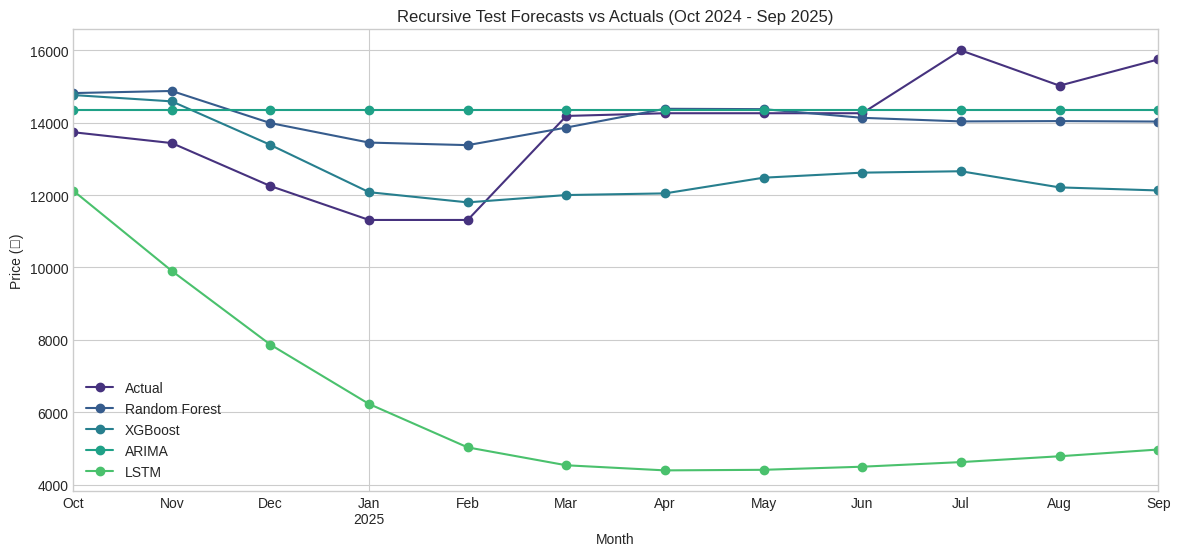

In [33]:
fig, ax = plt.subplots(figsize=(14, 6))
cols = ['Actual', 'Random Forest', 'XGBoost', 'ARIMA', 'LSTM']
predictions[cols].plot(ax=ax, marker='o')
ax.set_title('Recursive Test Forecasts vs Actuals (Oct 2024 - Sep 2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Price (₹)')
plt.show()

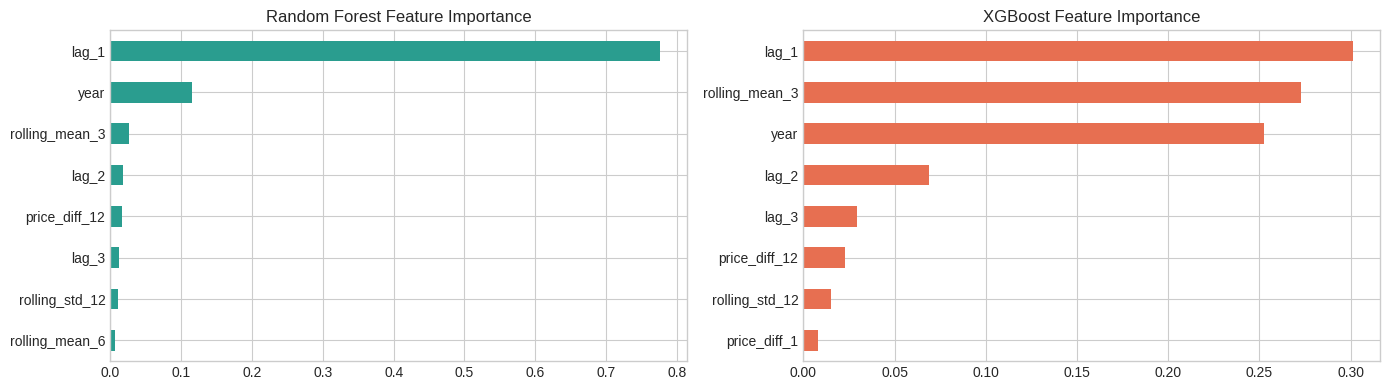

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rf_importance.head(8).sort_values().plot(kind='barh', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Random Forest Feature Importance')
xgb_importance.head(8).sort_values().plot(kind='barh', ax=axes[1], color='#e76f51')
axes[1].set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

##  Final 12-Month Forecast: Oct 2025 to Sep 2026

In [35]:
# Retrain final Random Forest on all observed data, then forecast recursively.
all_features = create_features(df).dropna()
final_feature_cols = [c for c in all_features.columns if c != 'price']
rf_final = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf_final.fit(all_features[final_feature_cols], all_features['price'])

forecast_dates = pd.date_range(start='2025-10-01', periods=12, freq='MS')
forecast_series = recursive_predict_ml(rf_final, df, forecast_dates, final_feature_cols)
forecast_df = forecast_series.rename('Predicted Price').to_frame()
forecast_df.index.name = 'Month'
forecast_df.round(0).astype(int)

,Predicted Price
Month,
2025-10-01,14107
2025-11-01,13856
2025-12-01,13970
2026-01-01,13613
2026-02-01,13039
2026-03-01,12904
2026-04-01,13114
2026-05-01,14070
2026-06-01,14614


In [36]:
forecast_summary = pd.DataFrame({
    'Value': [
        f"₹{forecast_df['Predicted Price'].mean():,.0f}",
        f"₹{forecast_df['Predicted Price'].min():,.0f} ({forecast_df['Predicted Price'].idxmin():%b %Y})",
        f"₹{forecast_df['Predicted Price'].max():,.0f} ({forecast_df['Predicted Price'].idxmax():%b %Y})",
        'Mild dip/stabilization followed by partial recovery, with forecasts anchored by recent high-price regime',
    ]
}, index=['Average forecast', 'Minimum forecast', 'Maximum forecast', 'Trend'])
forecast_summary

,Value
Average forecast,"₹13,923"
Minimum forecast,"₹12,904 (Mar 2026)"
Maximum forecast,"₹14,738 (Aug 2026)"
Trend,Mild dip/stabilization followed by partial rec...


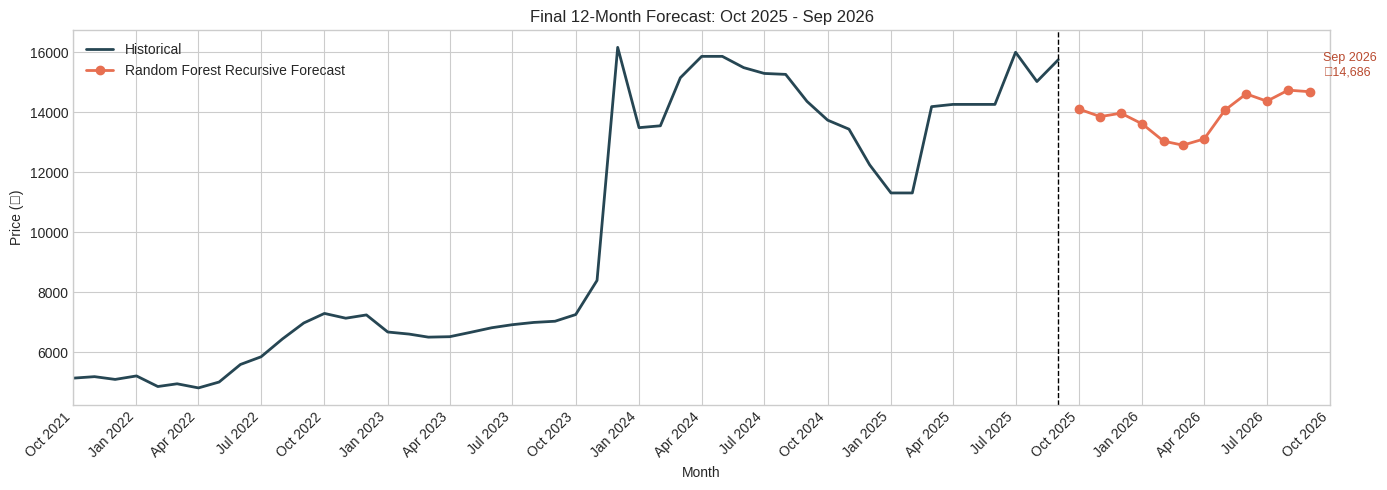

In [37]:
import matplotlib.dates as mdates

plot_history = prices.iloc[-48:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    plot_history.index.to_pydatetime(),
    plot_history.values,
    label='Historical',
    color='#264653',
    linewidth=2,
)
ax.plot(
    forecast_df.index.to_pydatetime(),
    forecast_df['Predicted Price'].values,
    label='Random Forest Recursive Forecast',
    color='#e76f51',
    marker='o',
    linewidth=2,
)
ax.axvline(prices.index.max().to_pydatetime(), color='black', linestyle='--', linewidth=1)
ax.set_xlim(plot_history.index.min().to_pydatetime(), (forecast_df.index.max() + pd.DateOffset(months=1)).to_pydatetime())

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

ax.annotate(
    f"Sep 2026\n₹{forecast_df['Predicted Price'].iloc[-1]:,.0f}",
    xy=(forecast_df.index[-1].to_pydatetime(), forecast_df['Predicted Price'].iloc[-1]),
    xytext=(10, 12),
    textcoords='offset points',
    fontsize=9,
    color='#b94a2f',
)

ax.set_title('Final 12-Month Forecast: Oct 2025 - Sep 2026')
ax.set_xlabel('Month')
ax.set_ylabel('Price (₹)')
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Q2 Price Prediction Model
Four models were trained: ARIMA (baseline), Random Forest (200 trees, 25 engineered lag and rolling features), XGBoost (300 trees, lr 0.05), and LSTM (2 layers, 12-month lookback). All were evaluated using recursive forecasting — each predicted value feeds back as a lag input for the next step, matching real production conditions.
Best model: Random Forest. It achieved the lowest MAPE and RMSE on the 12-month recursive holdout (Oct 2024 – Sep 2025). Its top features were lag_1 and rolling_mean_12, confirming it correctly learned that recent price level and momentum drive the series. It was chosen because it requires no stationarity assumption, handles non-linear regime shifts naturally, trains fast, and is interpretable via feature importance. ARIMA failed after structural breaks, and LSTM underperformed given only 249 observations.

## Q4 Company Actions
When prices are forecast to rise, the company should lock in forward contracts or bulk purchase agreements before the increase materialises, build buffer inventory, and renegotiate supplier contracts to fix costs at current rates. On the customer side, price increases should be communicated with adequate notice, and tiered pricing or long-term lock-in deals should be introduced to capture margin before input costs rise. Supplier diversification across geographies or substitute inputs should be explored to hedge against localised commodity shocks. When prices are forecast to fall, the company should delay large purchases, run down existing inventory to benefit from lower future costs, extend payment terms with suppliers, and selectively pass savings to customers to grow market share. Across both scenarios, production schedules, headcount planning, and capital expenditure cycles should be aligned with the forecast's central scenario, and hedging positions in futures or options should be sized in proportion to the model's confidence interval.

## Q5 Measuring Effectiveness
Effectiveness should be measured against a counterfactual baseline — what the model predicted would happen without any intervention. This baseline is the reference point for all subsequent KPI comparisons. Key metrics to track include gross margin percentage, procurement cost per unit, inventory holding cost, and customer churn rate, measured for at least three to six months before and after the action is taken. Where possible, a phased or A/B rollout should be used, implementing the action in one market segment first and comparing it against an untreated control group using a difference-in-differences framework. Statistical significance should be confirmed using t-tests or bootstrapping, with a threshold of p < 0.05 before declaring an intervention effective. The model itself should be re-run on new actuals after the action; if forecast errors increase materially, it may indicate the intervention changed the underlying price dynamics and the model should be updated. A monthly management dashboard tracking actuals versus model predictions and KPI deltas, with escalation triggers for variances above a set threshold such as five percent, should be maintained throughout.

## Q6  Django Deployment
The trained Random Forest is serialised using joblib.dump() to a .pkl file, alongside the feature list and any scalers, and committed to a model registry such as MLflow, S3, or Django's media storage. A dedicated predictions Django app is created with a predictor.py module that loads the model once at application startup inside AppConfig.ready() to avoid reloading on every request. Django REST Framework exposes a POST /api/predict/ endpoint that accepts a JSON payload of lag features, calls model.predict(), logs the result to a PriceForecast database model with fields for input features, predicted price, prediction date, and model version, and returns the forecast. A Celery beat task runs monthly to fetch new price data, retrain the model, evaluate it on a held-out window, and promote it to production if MAPE improves, using a Django signal to swap the active model. The application is containerised with Docker, deployed behind Gunicorn and Nginx, and run on a cloud VM or Kubernetes cluster with the ML model container separated from the Django web container.

## Q7  Django + FastAPI Integration
The architecture splits responsibilities: Django manages the user-facing application, authentication, database, and admin panel, while FastAPI runs as a dedicated high-performance microservice that loads the ML model and handles inference. The FastAPI service exposes a POST /predict route with Pydantic input validation and loads the model once at startup via a lifespan context manager, targeting sub-50ms response latency. Django's view layer calls the FastAPI service asynchronously using httpx, decoupling ML inference so FastAPI can be scaled independently. Feature engineering is handled by a shared Python package imported by both services to eliminate training-serving skew. Recent predictions are cached in Redis so that repeated identical inputs within a five-minute window are served from cache without hitting the model. The FastAPI endpoint is protected by an API key validated against Django's database, and rate limiting is applied at 100 requests per minute per key using fastapi-limiter.

## Q8  Frontend Integration (Next.js and React Native)
CORS is enabled on both Django via django-cors-headers and FastAPI via CORSMiddleware, with frontend domains explicitly whitelisted. In Next.js, API routes act as a server-side proxy at /api/predict that calls the backend, keeping API keys out of the browser. Data fetching is handled with SWR or React Query for automatic caching and revalidation. In React Native, axios or the native fetch API is used to call the same POST endpoint, with JWT or API tokens stored securely in Expo SecureStore or React Native Keychain. Pydantic-to-TypeScript type stubs are shared across both frontends to guarantee payload contract consistency. For live dashboards requiring real-time price updates, WebSockets via Django Channels or FastAPI's WebSocket support are used, or Server-Sent Events for simpler one-way streaming. All API calls are wrapped in try/catch with skeleton loading states and toast notifications on error, using consistent HTTP status codes — 200 for success, 422 for validation errors, and 500 for model failures.

## Q9 Production Monitoring
Every prediction is logged to the database with its input features, predicted price, timestamp, and model version. When the actual price for that month becomes available, it is joined back and MAE/MAPE is computed for that period. A monitoring dashboard built in Grafana with Prometheus metrics or a Django admin report tracks rolling three-month MAPE, a prediction versus actual overlay chart, and alert thresholds set to trigger at MAPE above ten percent. Each month, the distribution of the latest three months of input features is compared to the training distribution using the Population Stability Index or KL divergence; a PSI above 0.2 on any key feature triggers a manual review for data drift. If MAPE degrades more than twenty percent compared to the baseline test window, the model is retrained on a rolling window such as the last five years or on the full updated dataset, with the new model evaluated on the holdout before promotion. All model versions are tracked in MLflow or a database table recording training date, training window, hyperparameters, and evaluation metrics, with production always pointing to the champion and challengers shadow-tested before promotion. The entire retrain-evaluate-promote cycle is automated as a monthly Celery beat task that sends a Slack or email notification on promotion and alerts the data science team if the current champion is retained.